<a href="https://colab.research.google.com/github/kishoredage/letter_recognizer/blob/main/xgboost_for_time_series.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error


In [19]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
df = pd.read_csv(url, header=0, index_col=0, parse_dates= True)
df.columns = ['Passengers']

In [20]:
# Step 1 — log transform (handles multiplicative seasonality)
df['log_pass'] = np.log(df['Passengers'])

In [21]:
# step 2 - build features(everything from step 3)
df['lag_1'] = df['log_pass'].shift(1)
df['lag_2'] = df['log_pass'].shift(2)
df['lag_3'] = df['log_pass'].shift(3)
df['lag_12'] = df['log_pass'].shift(12)
df['rolling_mean_3'] = df['log_pass'].shift(1).rolling(3).mean()
df['rolling_mean_12'] = df['log_pass'].shift(1).rolling(12).mean()
df['rolling_std_3'] = df['log_pass'].shift(1).rolling(3).std()

In [22]:
#step 3 -add time based features
df['month'] = df.index.month   # 1 to 12
df['year'] = df.index.year     #1949 to 1960


In [23]:
# step 4 -drop NaN rows
df = df.dropna()

In [24]:
# step 5 - feature and target
feature_cols = ['lag_1','lag_2','lag_3','lag_12',
                'rolling_mean_3','rolling_mean_12',
                'rolling_std_3','month','year']

x = df[feature_cols]
y = df['log_pass']  # predicting log scale


In [25]:
# step 6 - time based split(never random)
split = int(len(df) * 0.8)
x_train, x_test = x.iloc[:split],x.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

In [26]:
# step 7 - train XGBoost
model = XGBRegressor(
    n_estimator=100,  # number of trees
    learning_rate=0.1, # how fasst it learns
    max_depth=3,     # tree depth
    random_state = 42
)

model.fit(x_train,y_train)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [05:42:04] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimator" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimator=100,
             n_estimators=None, n_jobs=None, ...)

In [27]:
# step 8 - predict
pred_log = model.predict(x_test)

In [28]:
#step 9 convert back from log scale
pred_actual = np.exp(pred_log)
y_actual = np.exp(y_test)

In [29]:
# step 10 - evaluate
mae = mean_absolute_error(y_actual, pred_actual)
print(f"XGBoost MAE: {mae:.2f}")


XGBoost MAE: 41.86


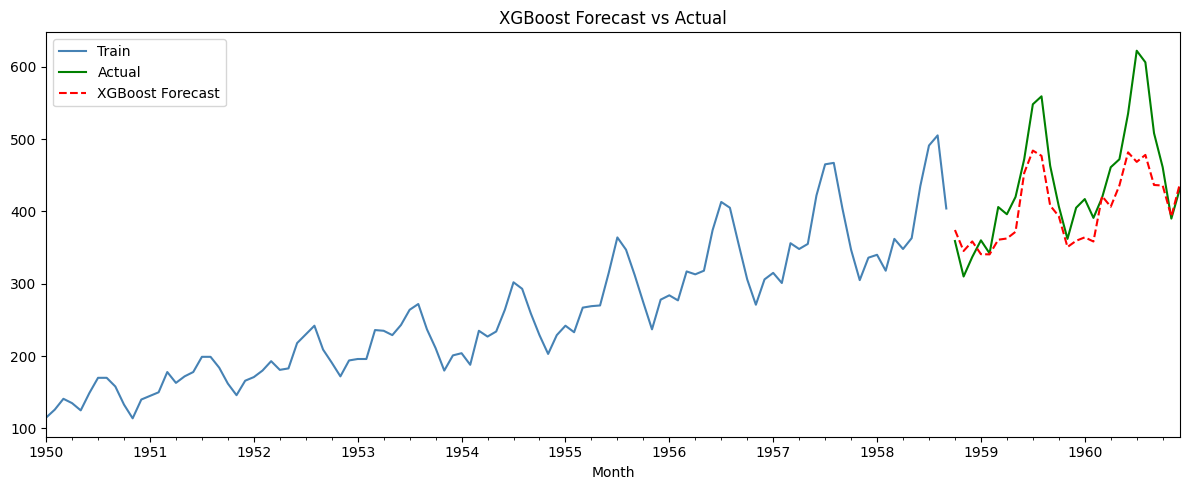

In [30]:
# step 11 - plot
plt.figure(figsize=(12,5))
np.exp(y.iloc[:split]).plot(label='Train',color='steelblue')
y_actual.plot(label='Actual',color='green')
pd.Series(pred_actual, index=x_test.index).plot(
    label='XGBoost Forecast',color='red',linestyle='--'
)
plt.title('XGBoost Forecast vs Actual')
plt.legend()
plt.tight_layout()
plt.show()

In [31]:
# plotting Feature importance

importance = pd.Series(model.feature_importances_,index = feature_cols).sort_values(ascending = False)

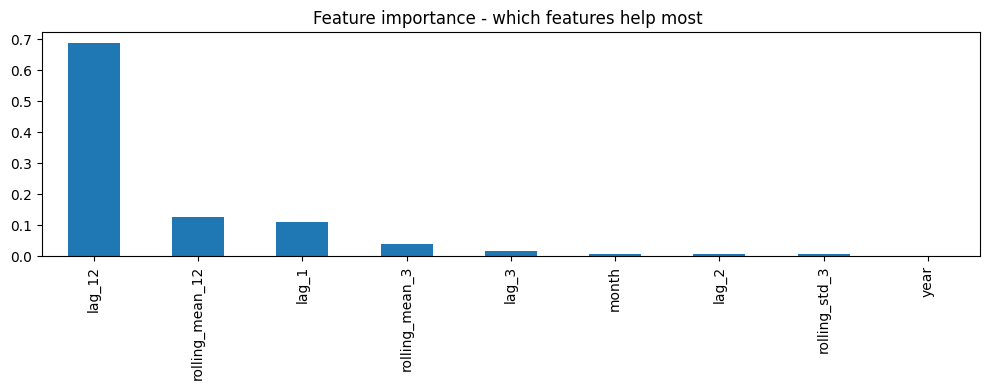

In [32]:
importance.plot(kind='bar',figsize=(10,4),
                title='Feature importance - which features help most ')
plt.tight_layout()
plt.show()

In [33]:
import numpy as np
from sklearn.metrics import*

In [34]:
def evaluate(actual, predicted , model_name):
  actual = np.array(actual)
  predicted = np.array(predicted)

  mae = mean_absolute_error(actual,predicted)
  rmse = np.sqrt(mean_squared_error(actual,predicted))
  mape = np.mean(np.abs((actual-predicted)/actual)) *100
  smape = np.mean(2* np.abs(predicted-actual)/
                  (np.abs(actual) + np.abs(predicted))) * 100

  print(f"\n{model_name}")
  print(f"MAE = {mae:.2f} (avg absolute error in passengers)")
  print(f"rmse = {rmse:.2f} (penalizes large error)")
  print(f"MAPE = {mape:.2f} (avg % error)")
  print(f"SMAPe = {smape:.2f}% (safer % error)")


In [35]:
evaluate(y_actual,pred_actual,"XGBoost")


XGBoost
MAE = 41.86 (avg absolute error in passengers)
rmse = 54.85 (penalizes large error)
MAPE = 8.80 (avg % error)
SMAPe = 9.33% (safer % error)
